# Comportamento da duração dos filmes ao longo do tempo

Este notebook é focado em visualizações temporais da duração dos filmes indicados ao Oscar de Melhor Filme. A intenção é tornar visível a evolução anual e por década, preservando a distinção entre observações individuais e agregações.

## 1. Configuração e carregamento

A base consumida é a camada `gold`, já enriquecida com `runtime_minutes`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [2]:
sns.set_theme(
    context="notebook",
    style="whitegrid",
    palette="colorblind",
)
plt.rcParams["figure.figsize"] = (18, 8)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)

In [3]:
def find_project_dir() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        if (candidate / "data" / "gold").exists() and candidate.name == "cinematic_chronos":
            return candidate
        nested = candidate / "cinematic_chronos"
        if (nested / "data" / "gold").exists():
            return nested
    raise FileNotFoundError("Não foi possível localizar cinematic_chronos/data/gold.")

In [4]:
PROJECT_DIR = find_project_dir()
GOLD_PATH = PROJECT_DIR / "data" / "gold" / "oscar_best_picture_nominees_runtime.parquet"
GOLD_PATH

WindowsPath('c:/WorkspaceHub/SourceHub/data-scientist/cinematic_chronos/data/gold/oscar_best_picture_nominees_runtime.parquet')

In [5]:
df = pd.read_parquet(GOLD_PATH)

expected_columns = {
    "year_film",
    "year_ceremony",
    "ceremony",
    "category",
    "canon_category",
    "name",
    "film",
    "winner",
    "runtime_minutes",
    "runtime_source",
    "tmdb_id",
}
missing_expected = expected_columns.difference(df.columns)
if missing_expected:
    raise ValueError(f"Colunas esperadas ausentes: {sorted(missing_expected)}")

analysis_df = df.copy()
analysis_df["decade"] = (analysis_df["year_film"] // 10) * 10
analysis_df["runtime_hours"] = analysis_df["runtime_minutes"] / 60
analysis_df["winner_label"] = np.where(analysis_df["winner"], "Vencedor", "Indicado")

print(f"Linhas: {len(analysis_df):,}")
print(f"Colunas: {analysis_df.shape[1]:,}")
print(f"Período dos filmes: {analysis_df['year_film'].min()}-{analysis_df['year_film'].max()}")
analysis_df.head()

Linhas: 621
Colunas: 14
Período dos filmes: 1927-2025


,year_film,year_ceremony,ceremony,category,canon_category,name,film,winner,runtime_minutes,runtime_source,tmdb_id,decade,runtime_hours,winner_label
0,1927,1928,1,OUTSTANDING PICTURE,BEST PICTURE,The Caddo Company,The Racket,False,88,tmdb,25876,1920,1.47,Indicado
1,1927,1928,1,OUTSTANDING PICTURE,BEST PICTURE,Fox,7th Heaven,False,119,tmdb,82474,1920,1.98,Indicado
2,1927,1928,1,OUTSTANDING PICTURE,BEST PICTURE,Paramount Famous Lasky,Wings,True,144,tmdb,28966,1920,2.40,Vencedor
3,1928,1929,2,OUTSTANDING PICTURE,BEST PICTURE,Feature Productions,Alibi,False,90,tmdb,14938,1920,1.50,Indicado
4,1928,1929,2,OUTSTANDING PICTURE,BEST PICTURE,Fox,In Old Arizona,False,95,tmdb,83989,1920,1.58,Indicado


## 2. Séries agregadas

Para reduzir ruído, calculamos média, mediana, desvio padrão e intervalo interquartil por ano. A média móvel de 10 anos ajuda a observar tendências de médio prazo sem esconder os pontos individuais.

In [6]:
yearly_runtime = (
    analysis_df.groupby("year_film", as_index=False)
    .agg(
        nominees=("film", "count"),
        runtime_mean=("runtime_minutes", "mean"),
        runtime_median=("runtime_minutes", "median"),
        runtime_q25=("runtime_minutes", lambda series: series.quantile(0.25)),
        runtime_q75=("runtime_minutes", lambda series: series.quantile(0.75)),
        runtime_min=("runtime_minutes", "min"),
        runtime_max=("runtime_minutes", "max"),
    )
    .sort_values("year_film")
)
yearly_runtime["mean_rolling_10y"] = yearly_runtime["runtime_mean"].rolling(10, min_periods=3).mean()
yearly_runtime["median_rolling_10y"] = yearly_runtime["runtime_median"].rolling(10, min_periods=3).mean()
yearly_runtime.head()

,year_film,nominees,runtime_mean,runtime_median,runtime_q25,runtime_q75,runtime_min,runtime_max,mean_rolling_10y,median_rolling_10y
0,1927,3,117.00,119.00,103.50,131.50,88,144,NaN,NaN
1,1928,5,103.40,101.00,95.00,113.00,90,118,NaN,NaN
2,1929,5,105.80,95.00,90.00,107.00,90,147,108.73,105.00
3,1930,5,96.20,101.00,90.00,102.00,83,105,105.60,104.00
4,1931,8,89.38,89.00,85.00,90.25,80,108,102.35,101.00


## 3. Pontos individuais e tendência linear

Cada ponto representa um filme indicado. A linha vermelha resume a tendência linear estimada visualmente pela regressão do `seaborn`.

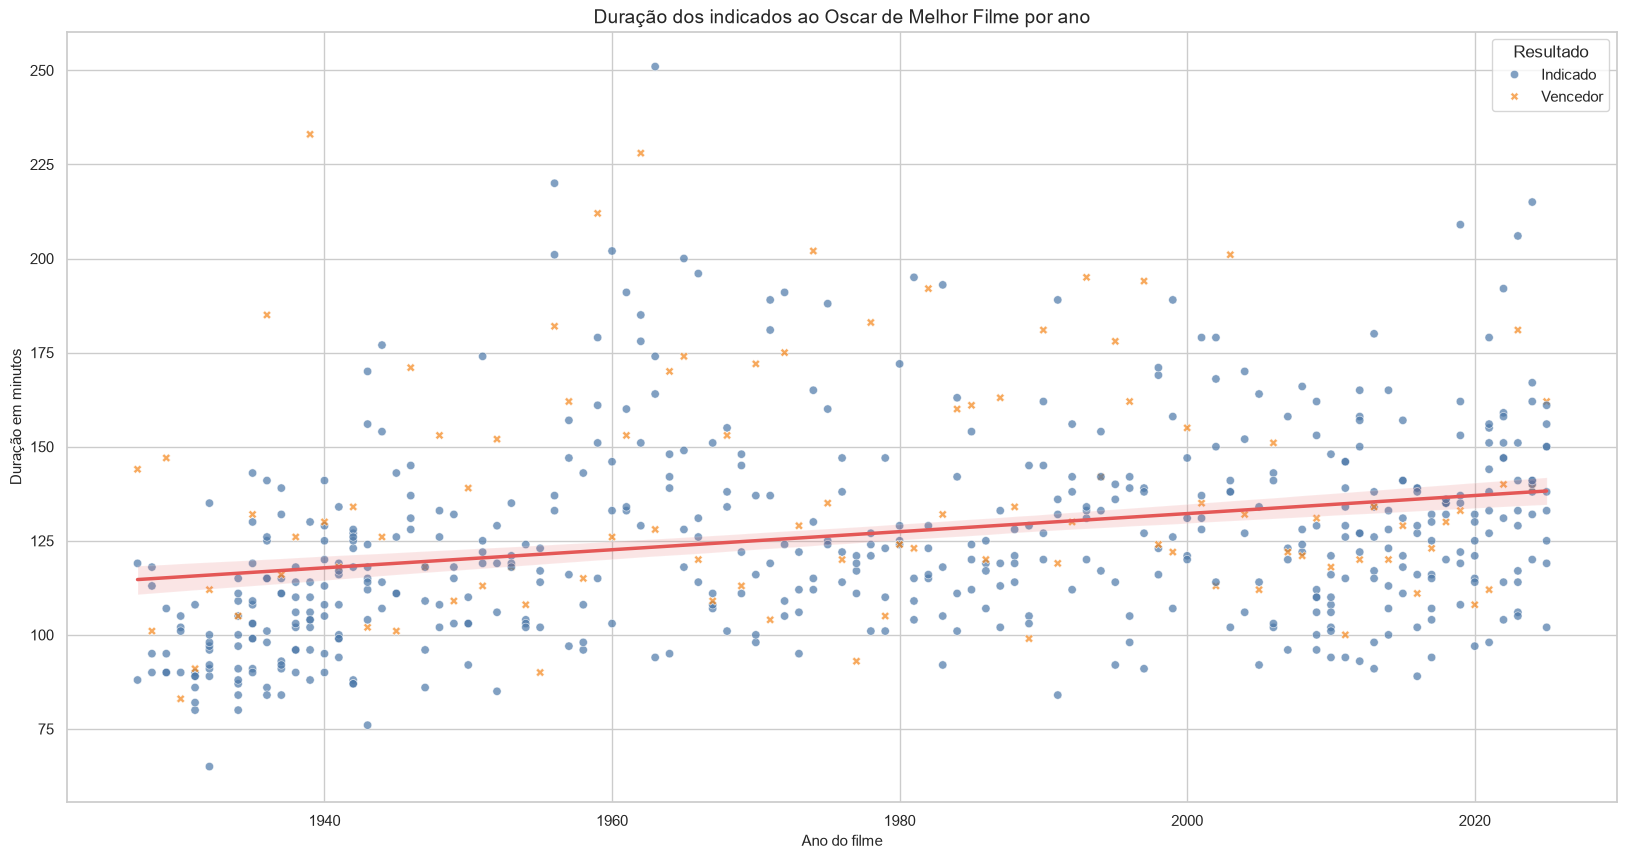

In [7]:
fig, ax = plt.subplots(figsize=(20, 10))
sns.scatterplot(
    data=analysis_df,
    x="year_film",
    y="runtime_minutes",
    hue="winner_label",
    style="winner_label",
    palette={"Indicado": "#4C78A8", "Vencedor": "#F58518"},
    alpha=0.7,
    ax=ax,
)
sns.regplot(
    data=analysis_df,
    x="year_film",
    y="runtime_minutes",
    scatter=False,
    line_kws={"color": "#E45756", "linewidth": 2.5, "label": "Tendência linear"},
    ax=ax,
)
ax.set_title("Duração dos indicados ao Oscar de Melhor Filme por ano")
ax.set_xlabel("Ano do filme")
ax.set_ylabel("Duração em minutos")
ax.legend(title="Resultado")
plt.show()

## 4. Média e mediana anual com média móvel

A média anual pode ser influenciada por filmes extremos. Por isso a mediana anual e as médias móveis são exibidas junto com ela.

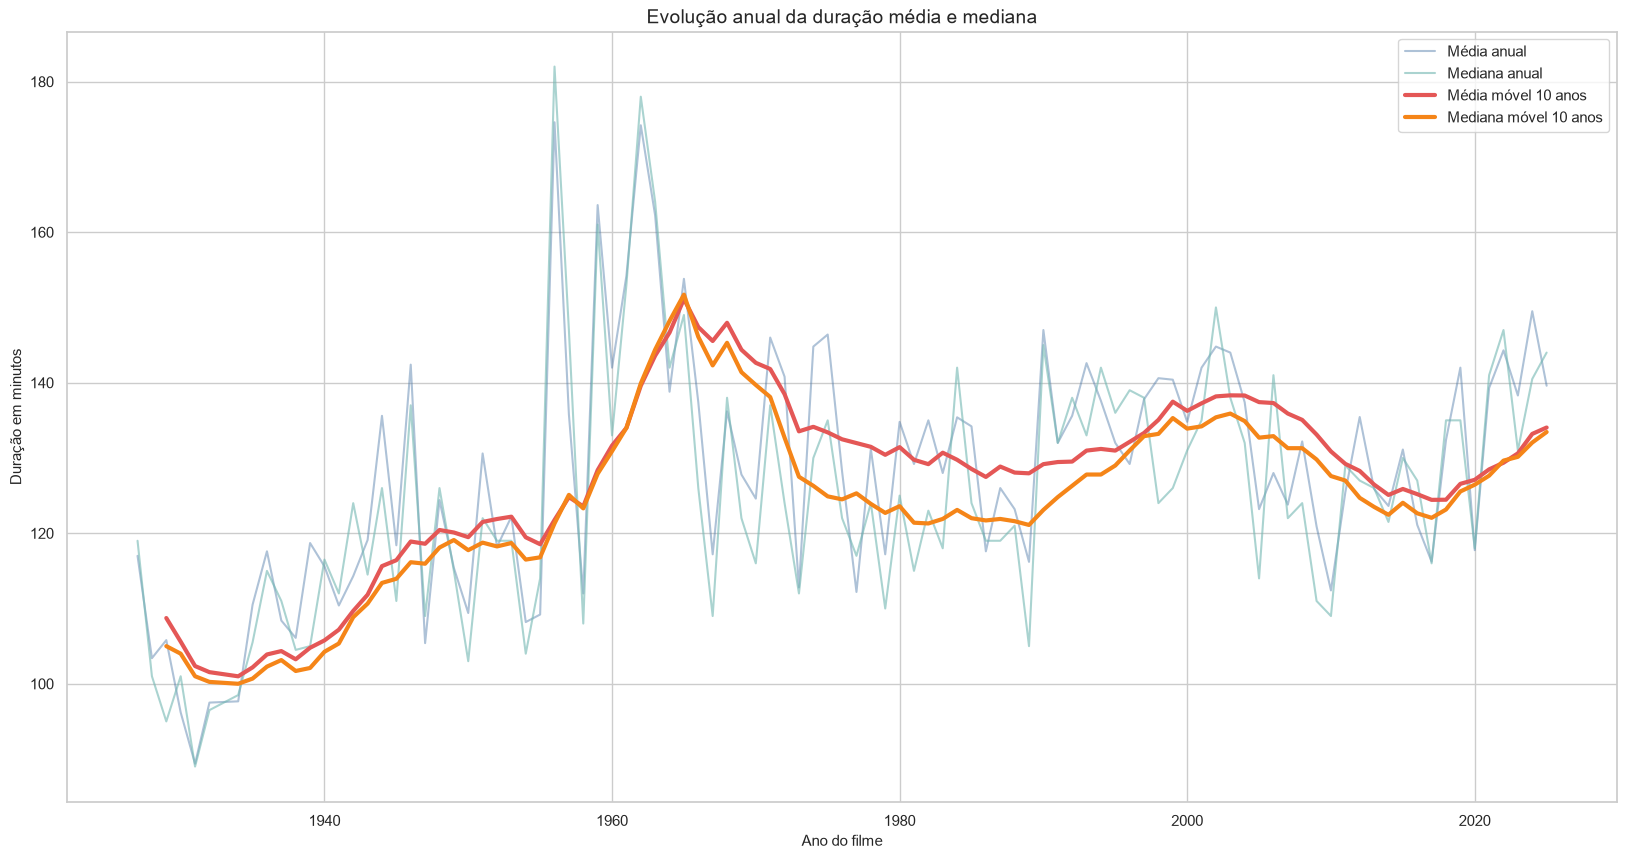

In [8]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.plot(
    yearly_runtime["year_film"],
    yearly_runtime["runtime_mean"],
    color="#4C78A8",
    alpha=0.45,
    linewidth=1.5,
    label="Média anual",
)
ax.plot(
    yearly_runtime["year_film"],
    yearly_runtime["runtime_median"],
    color="#72B7B2",
    alpha=0.6,
    linewidth=1.5,
    label="Mediana anual",
)
ax.plot(
    yearly_runtime["year_film"],
    yearly_runtime["mean_rolling_10y"],
    color="#E45756",
    linewidth=3,
    label="Média móvel 10 anos",
)
ax.plot(
    yearly_runtime["year_film"],
    yearly_runtime["median_rolling_10y"],
    color="#F58518",
    linewidth=3,
    label="Mediana móvel 10 anos",
)
ax.set_title("Evolução anual da duração média e mediana")
ax.set_xlabel("Ano do filme")
ax.set_ylabel("Duração em minutos")
ax.legend()
plt.show()

## 5. Faixa interquartil por ano

A banda entre o primeiro e o terceiro quartil mostra onde se concentra a metade central dos filmes em cada ano.

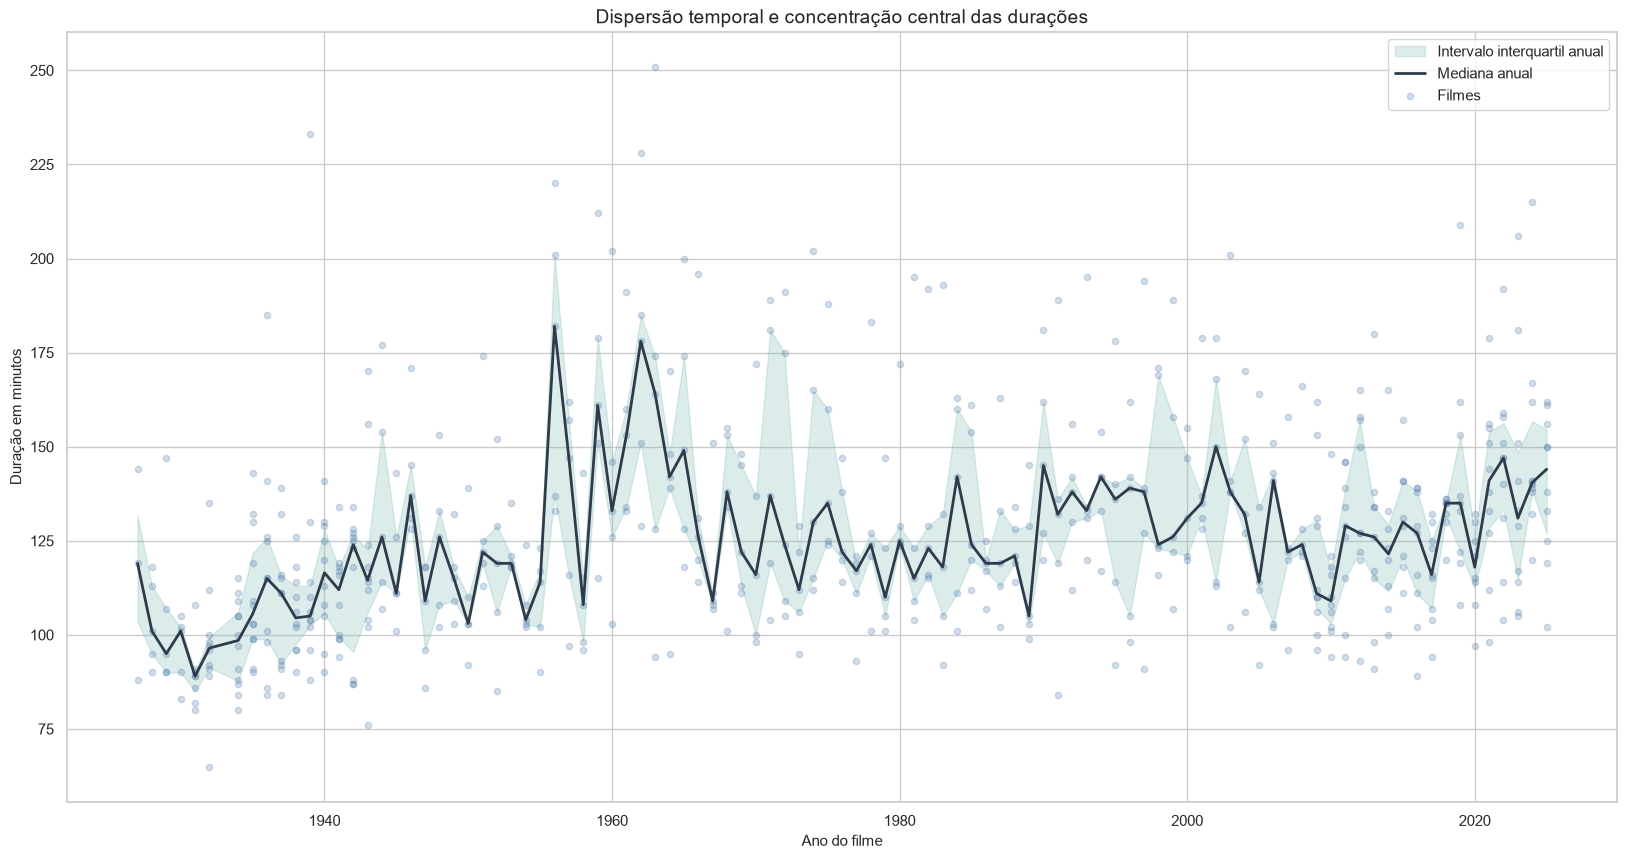

In [9]:
fig, ax = plt.subplots(figsize=(20, 10))
ax.fill_between(
    yearly_runtime["year_film"],
    yearly_runtime["runtime_q25"],
    yearly_runtime["runtime_q75"],
    color="#72B7B2",
    alpha=0.25,
    label="Intervalo interquartil anual",
)
ax.plot(
    yearly_runtime["year_film"],
    yearly_runtime["runtime_median"],
    color="#2F3A4A",
    linewidth=2,
    label="Mediana anual",
)
ax.scatter(
    analysis_df["year_film"],
    analysis_df["runtime_minutes"],
    color="#4C78A8",
    alpha=0.25,
    s=20,
    label="Filmes",
)
ax.set_title("Dispersão temporal e concentração central das durações")
ax.set_xlabel("Ano do filme")
ax.set_ylabel("Duração em minutos")
ax.legend()
plt.show()

## 6. Distribuição por década

Boxplots por década mostram como a distribuição completa muda ao longo do tempo, não apenas a média.

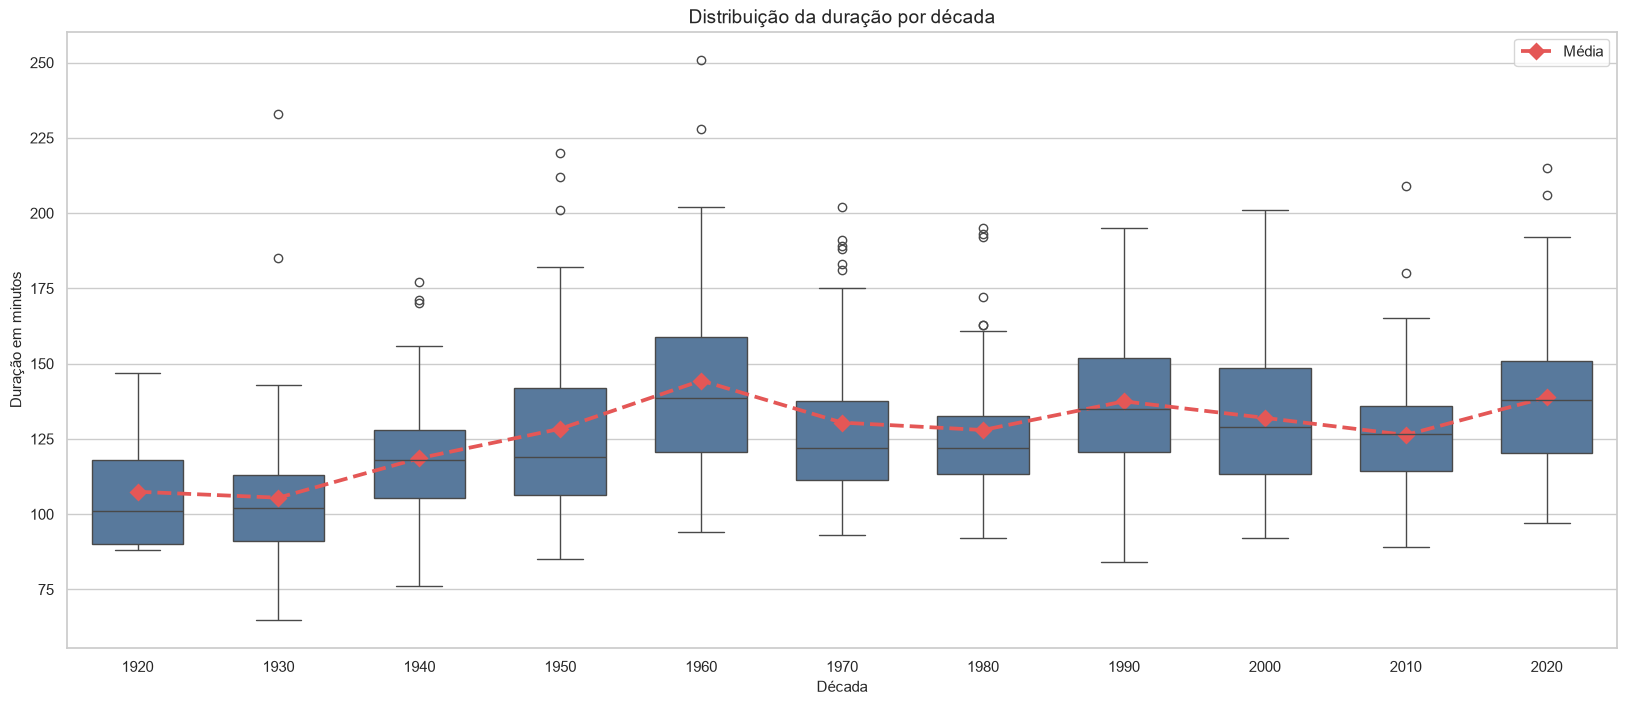

In [10]:
fig, ax = plt.subplots(figsize=(20, 8))
sns.boxplot(
    data=analysis_df,
    x="decade",
    y="runtime_minutes",
    color="#4C78A8",
    width=0.65,
    ax=ax,
)
sns.pointplot(
    data=analysis_df,
    x="decade",
    y="runtime_minutes",
    estimator="mean",
    errorbar=None,
    color="#E45756",
    markers="D",
    linestyles="--",
    label="Média",
    ax=ax,
)
ax.set_title("Distribuição da duração por década")
ax.set_xlabel("Década")
ax.set_ylabel("Duração em minutos")
plt.show()

## 7. Heatmap década versus faixa de duração

Esta visão transforma durações em faixas e mostra a composição relativa de cada década.

In [11]:
bins = [0, 90, 105, 120, 135, 150, 180, np.inf]
labels = ["até 90", "91-105", "106-120", "121-135", "136-150", "151-180", "181+"]
analysis_df["runtime_band"] = pd.cut(
    analysis_df["runtime_minutes"],
    bins=bins,
    labels=labels,
    right=True,
)

band_share = (
    analysis_df.pivot_table(
        index="decade",
        columns="runtime_band",
        values="film",
        aggfunc="count",
        observed=False,
    )
    .fillna(0)
)
band_share = band_share.div(band_share.sum(axis=1), axis=0)

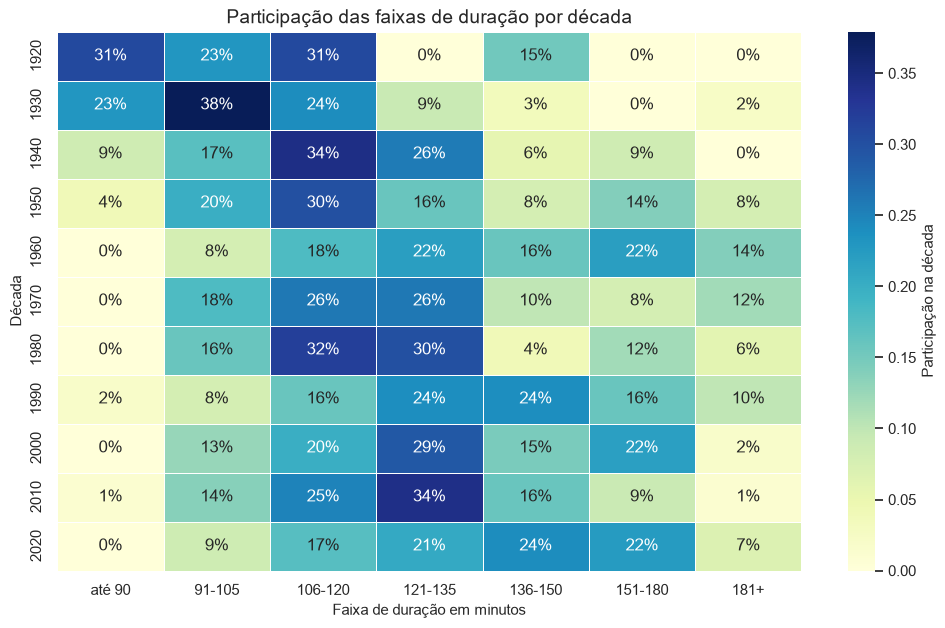

In [12]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    band_share,
    cmap="YlGnBu",
    annot=True,
    fmt=".0%",
    linewidths=0.5,
    cbar_kws={"label": "Participação na década"},
    ax=ax,
)
ax.set_title("Participação das faixas de duração por década")
ax.set_xlabel("Faixa de duração em minutos")
ax.set_ylabel("Década")
plt.show()

## 8. Maiores variações anuais na média

A tabela destaca anos com maiores saltos positivos e negativos na duração média. Ela ajuda a identificar períodos para investigação qualitativa posterior.

In [13]:
yearly_runtime["mean_change_minutes"] = yearly_runtime["runtime_mean"].diff()
changes = yearly_runtime.dropna(subset=["mean_change_minutes"]).copy()

largest_increases = changes.nlargest(10, "mean_change_minutes")[[
    "year_film", "nominees", "runtime_mean", "mean_change_minutes"
]]
largest_decreases = changes.nsmallest(10, "mean_change_minutes")[[
    "year_film", "nominees", "runtime_mean", "mean_change_minutes"
]]
largest_increases, largest_decreases

(    year_film  nominees  runtime_mean  mean_change_minutes
 28       1956         5        174.60                65.40
 31       1959         5        163.60                51.60
 46       1974         5        144.80                32.00
 62       1990         5        147.00                30.80
 18       1946         5        142.40                24.00
 93       2021        10        139.30                21.55
 43       1971         5        146.00                21.40
 23       1951         5        130.60                21.20
 34       1962         5        174.20                20.00
 20       1948         5        124.40                19.00,
     year_film  nominees  runtime_mean  mean_change_minutes
 29       1957         5        135.80               -38.80
 19       1947         5        105.40               -37.00
 45       1973         5        112.80               -28.00
 92       2020         8        117.75               -24.25
 30       1958         5        112.00 

## 9. Leitura visual

- Use os pontos individuais para avaliar dispersão e filmes extremos.
- Use média, mediana e média móvel para observar tendência temporal sem depender de um único ano.
- Use boxplots e heatmap para comparar a distribuição completa entre décadas.
- Para conclusão inferencial, combine estas visualizações com regressão linear, p-valor, intervalo de confiança e diagnóstico de resíduos.